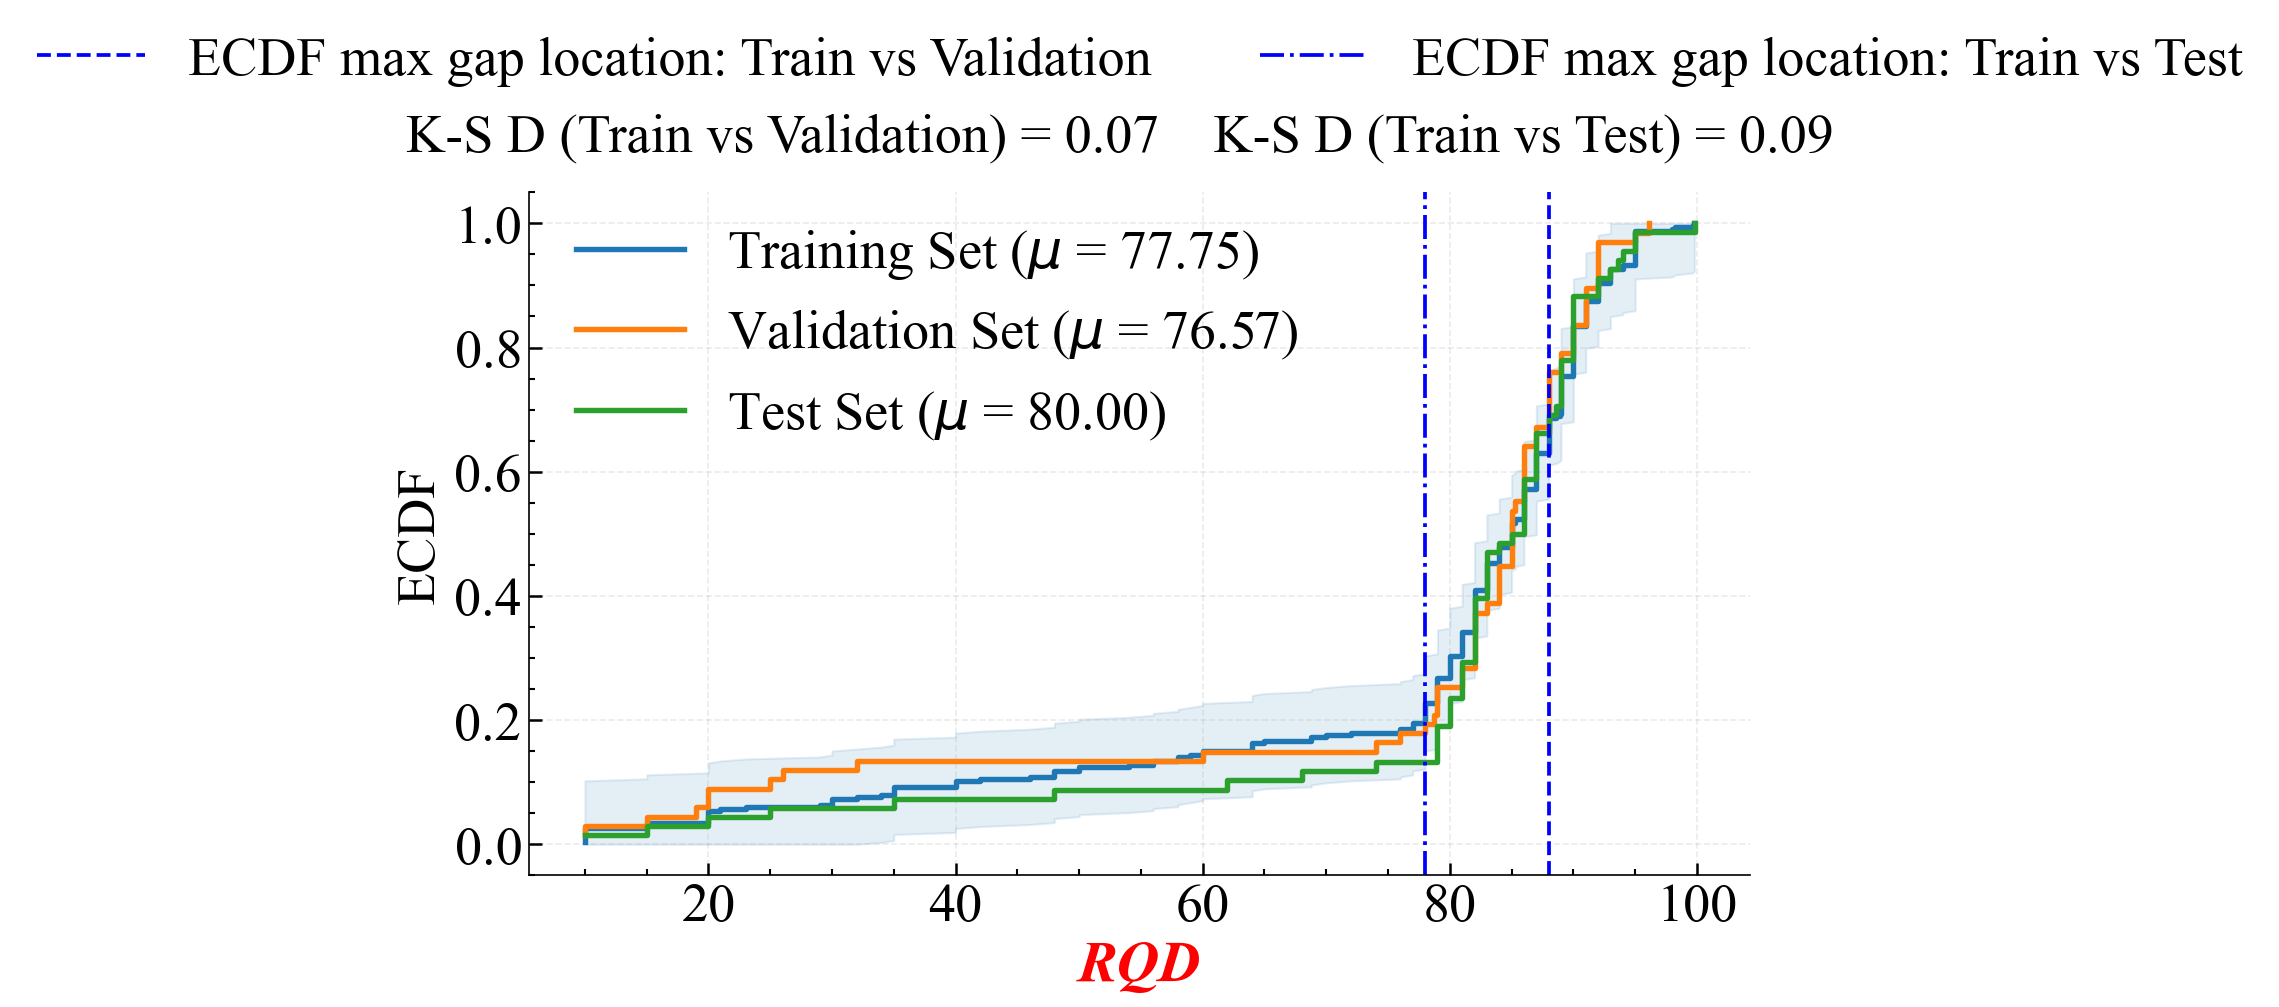

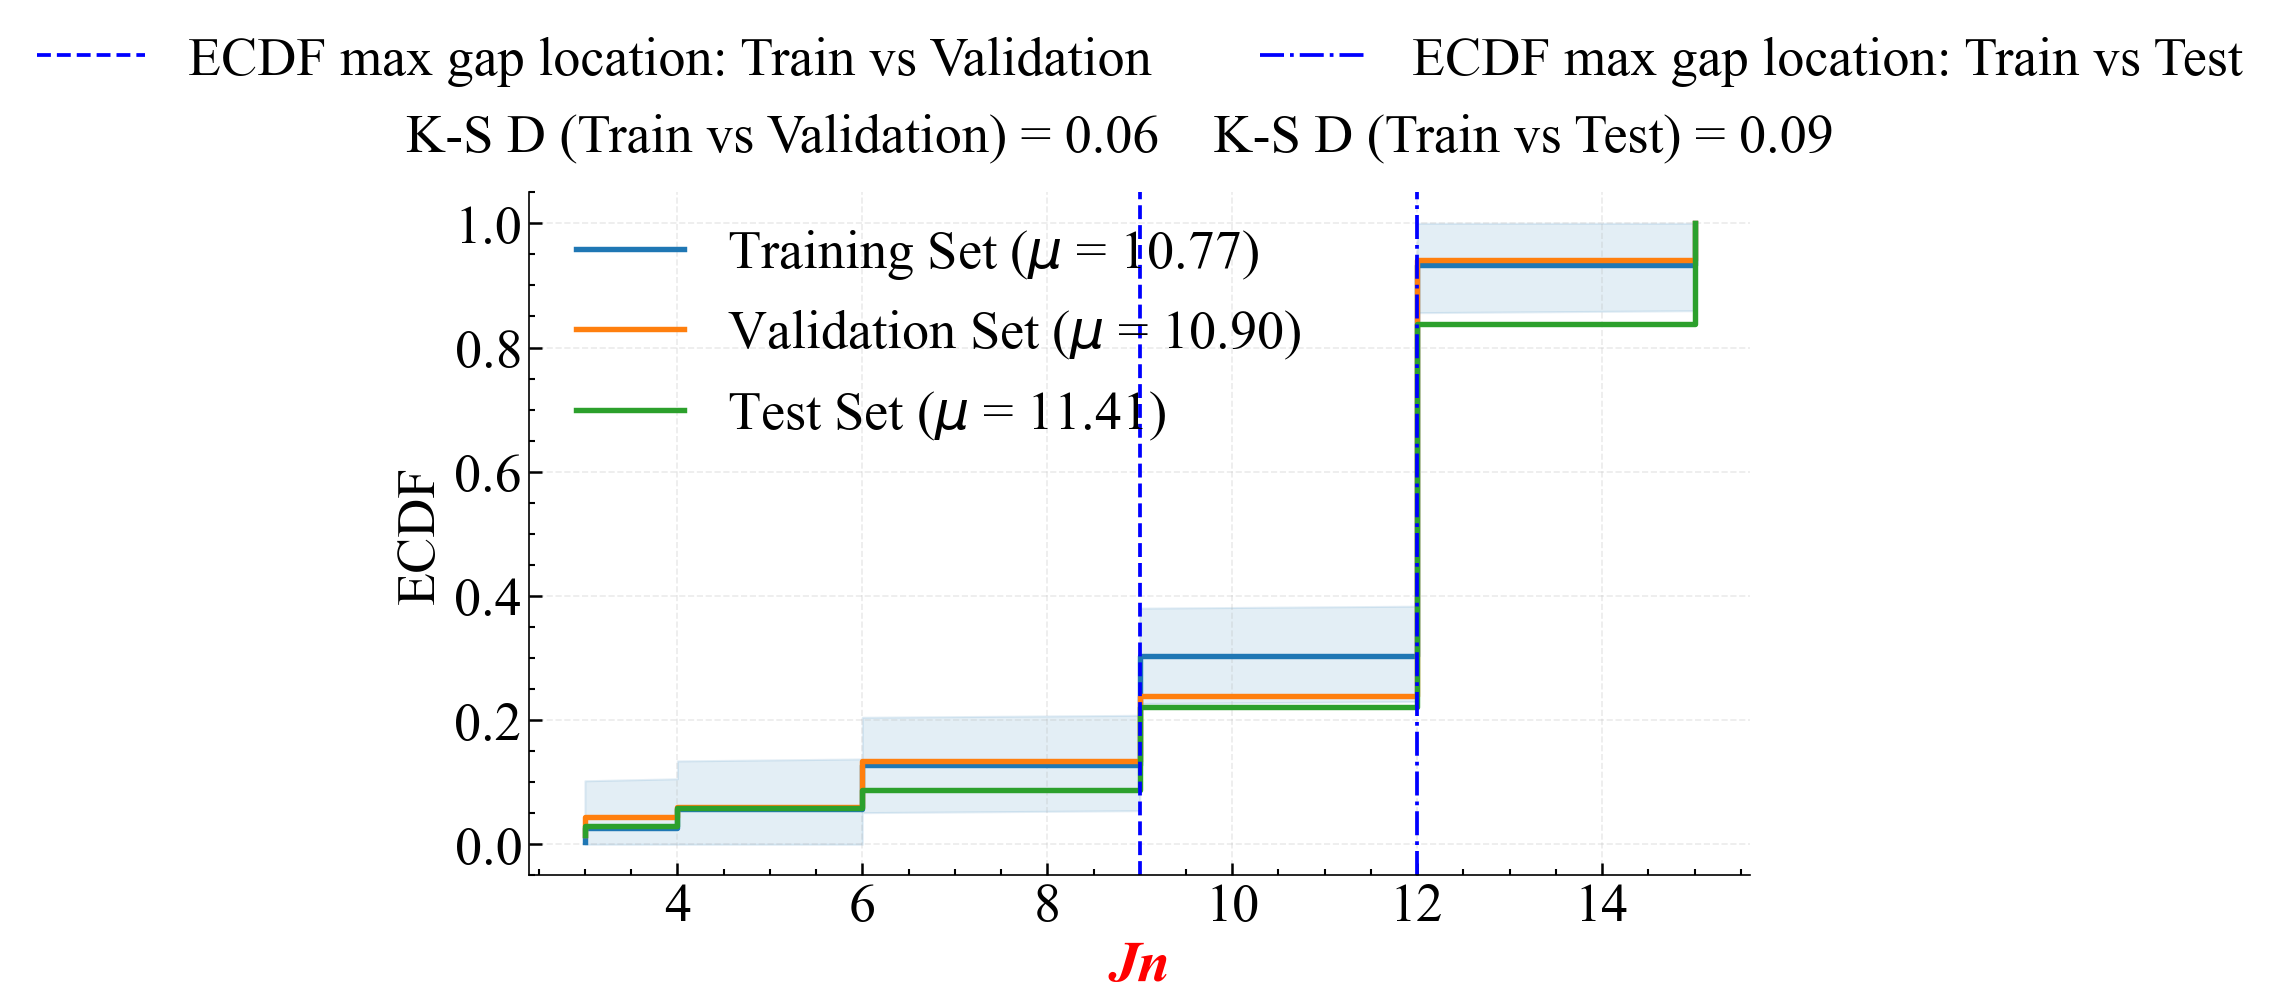

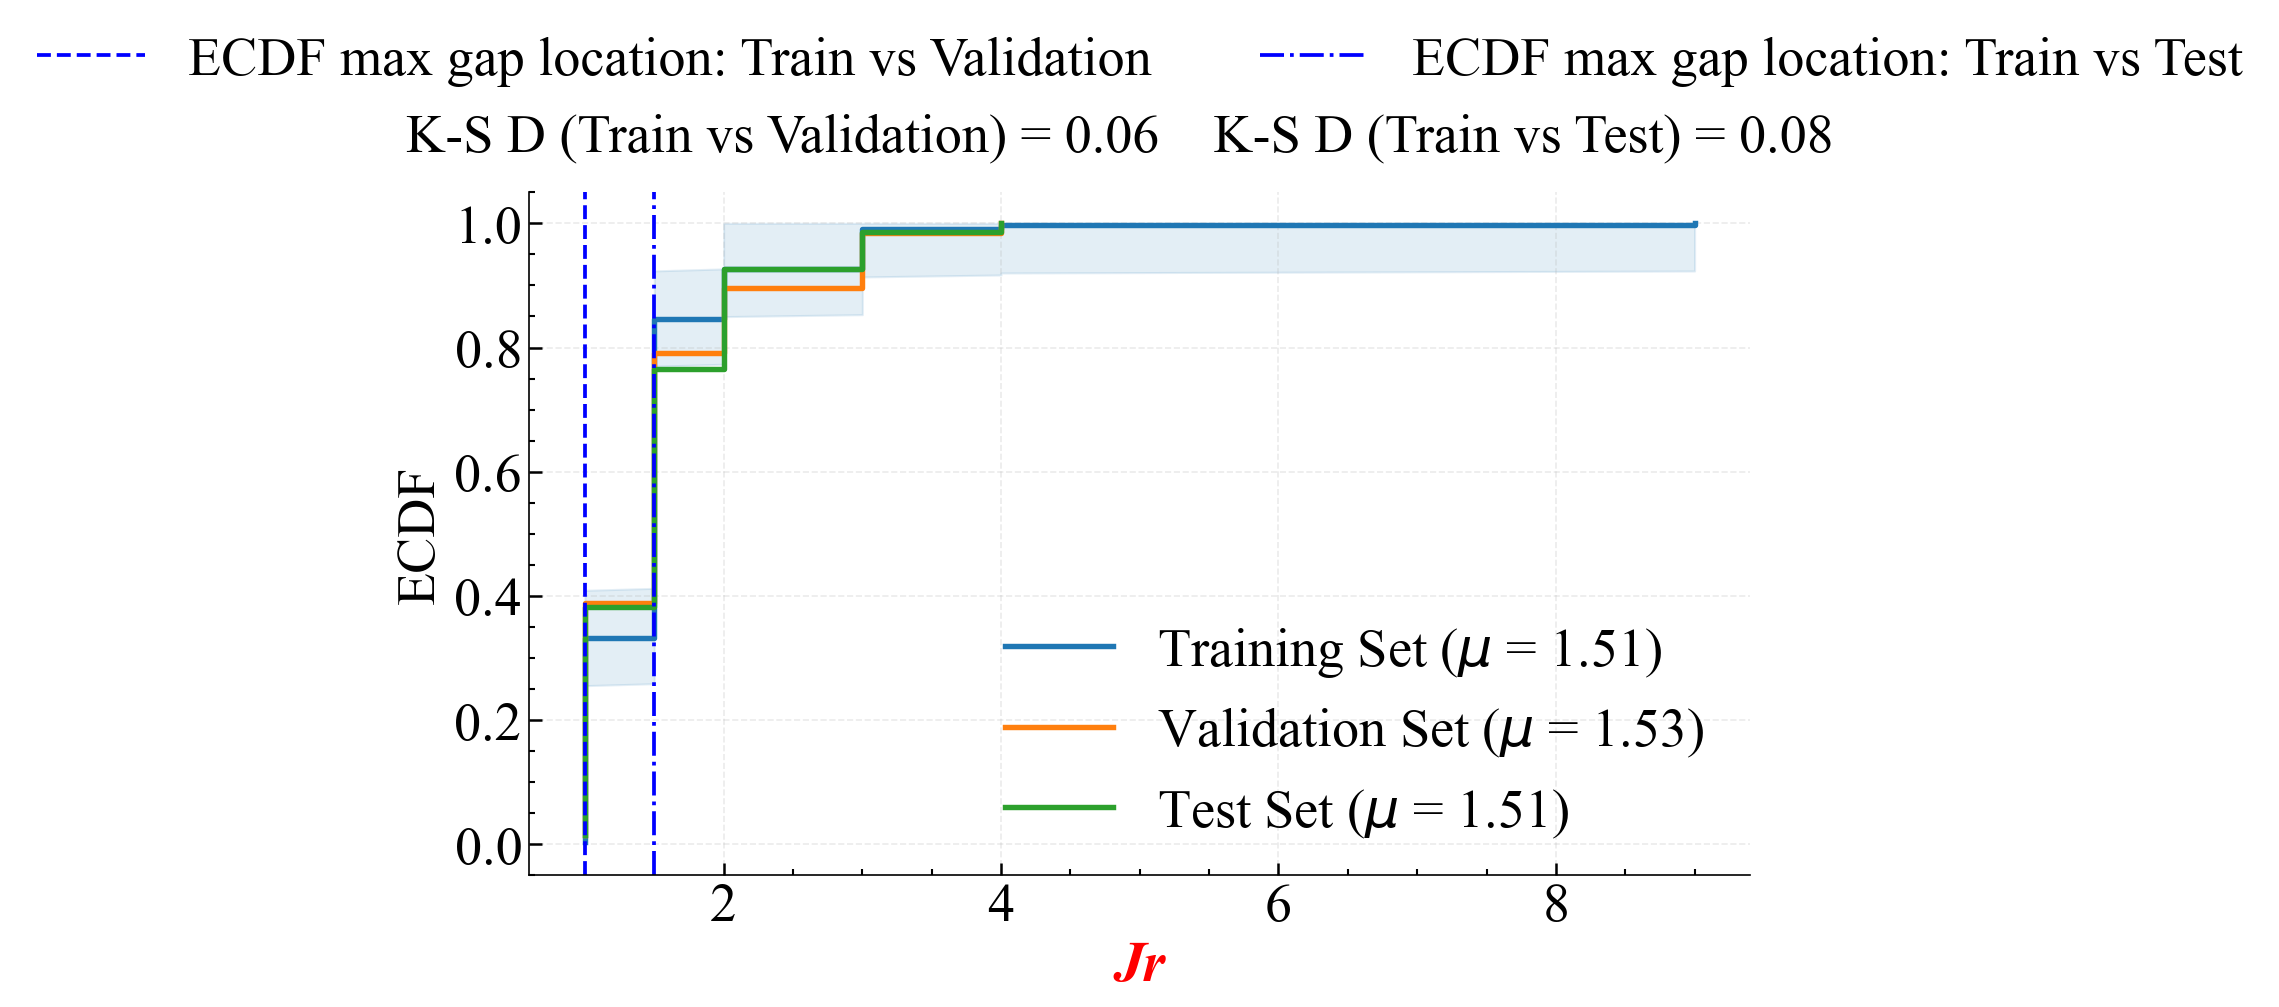

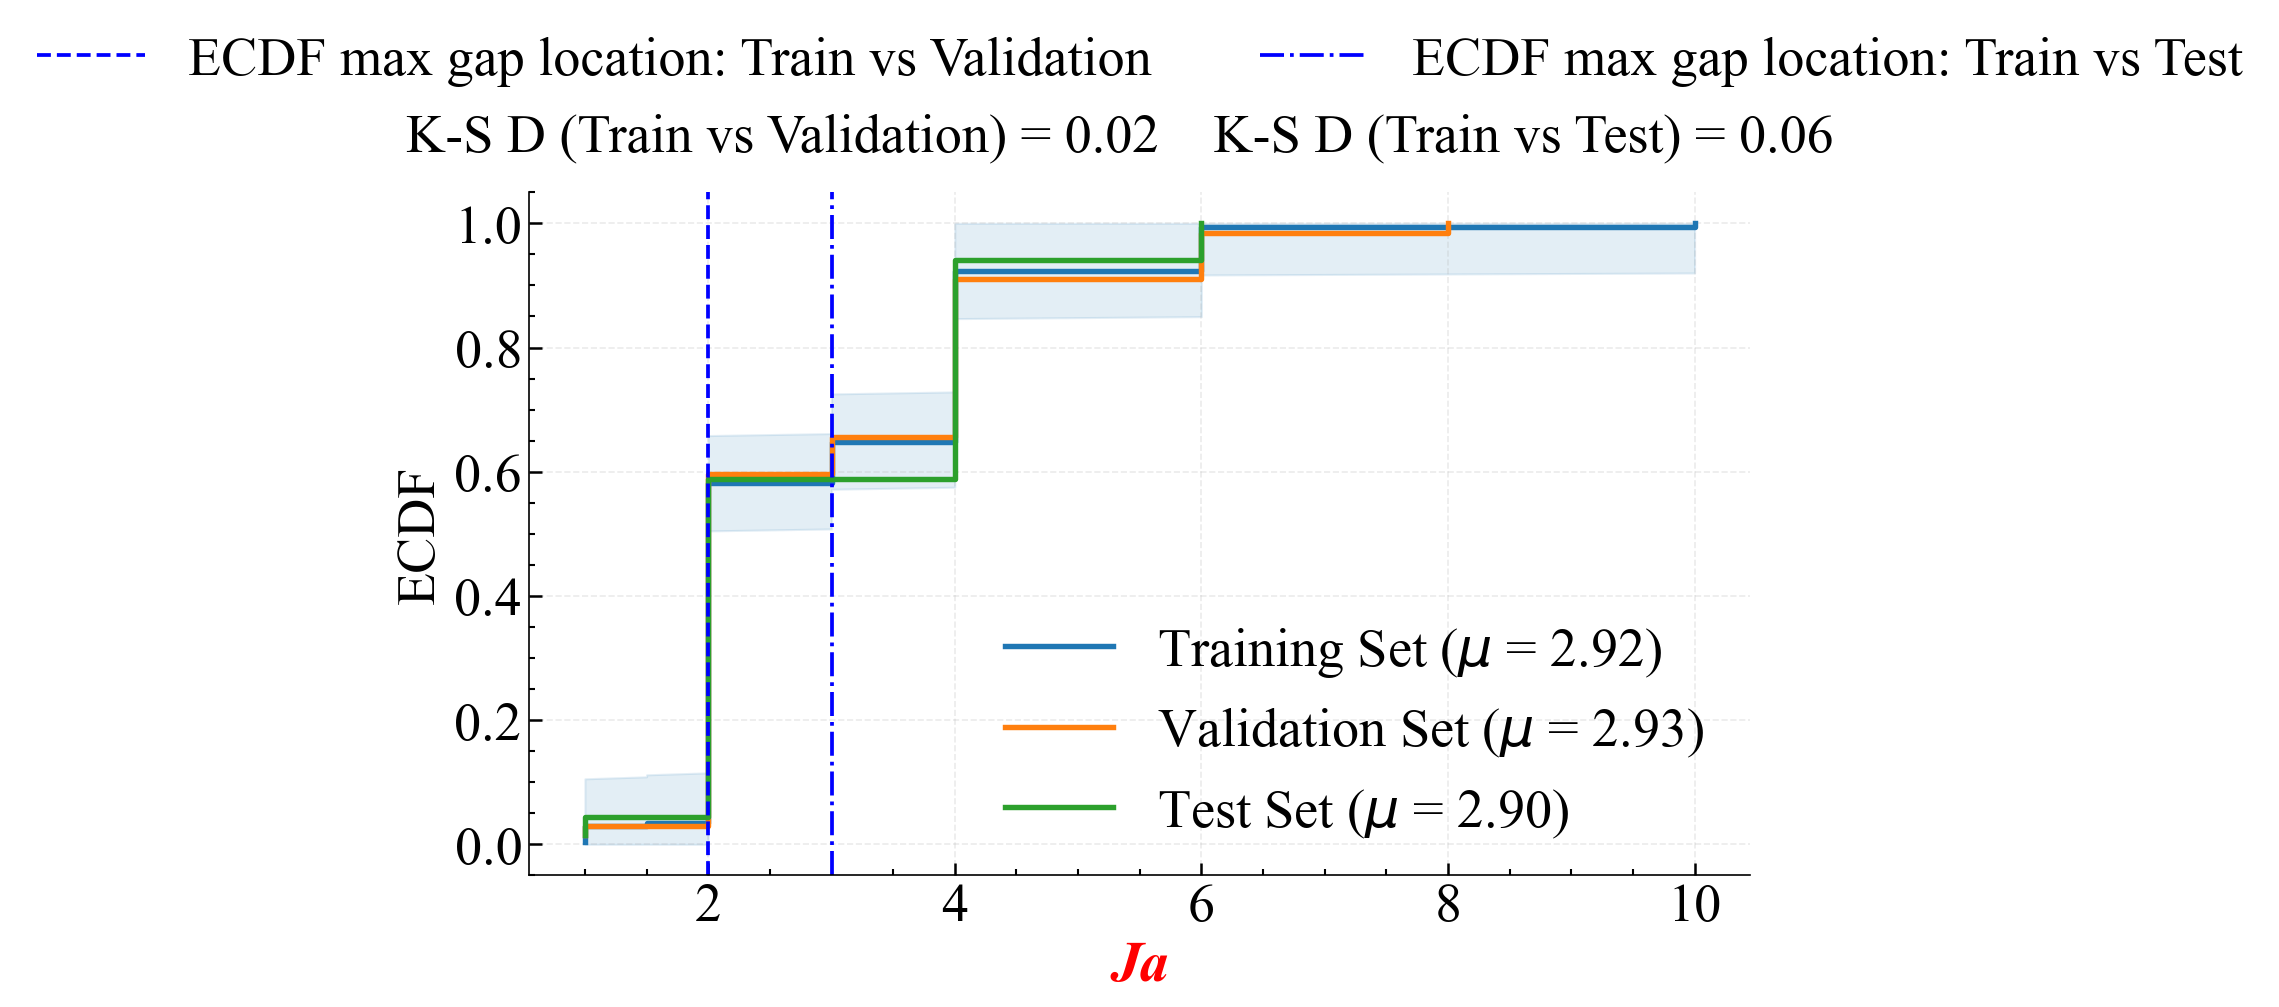

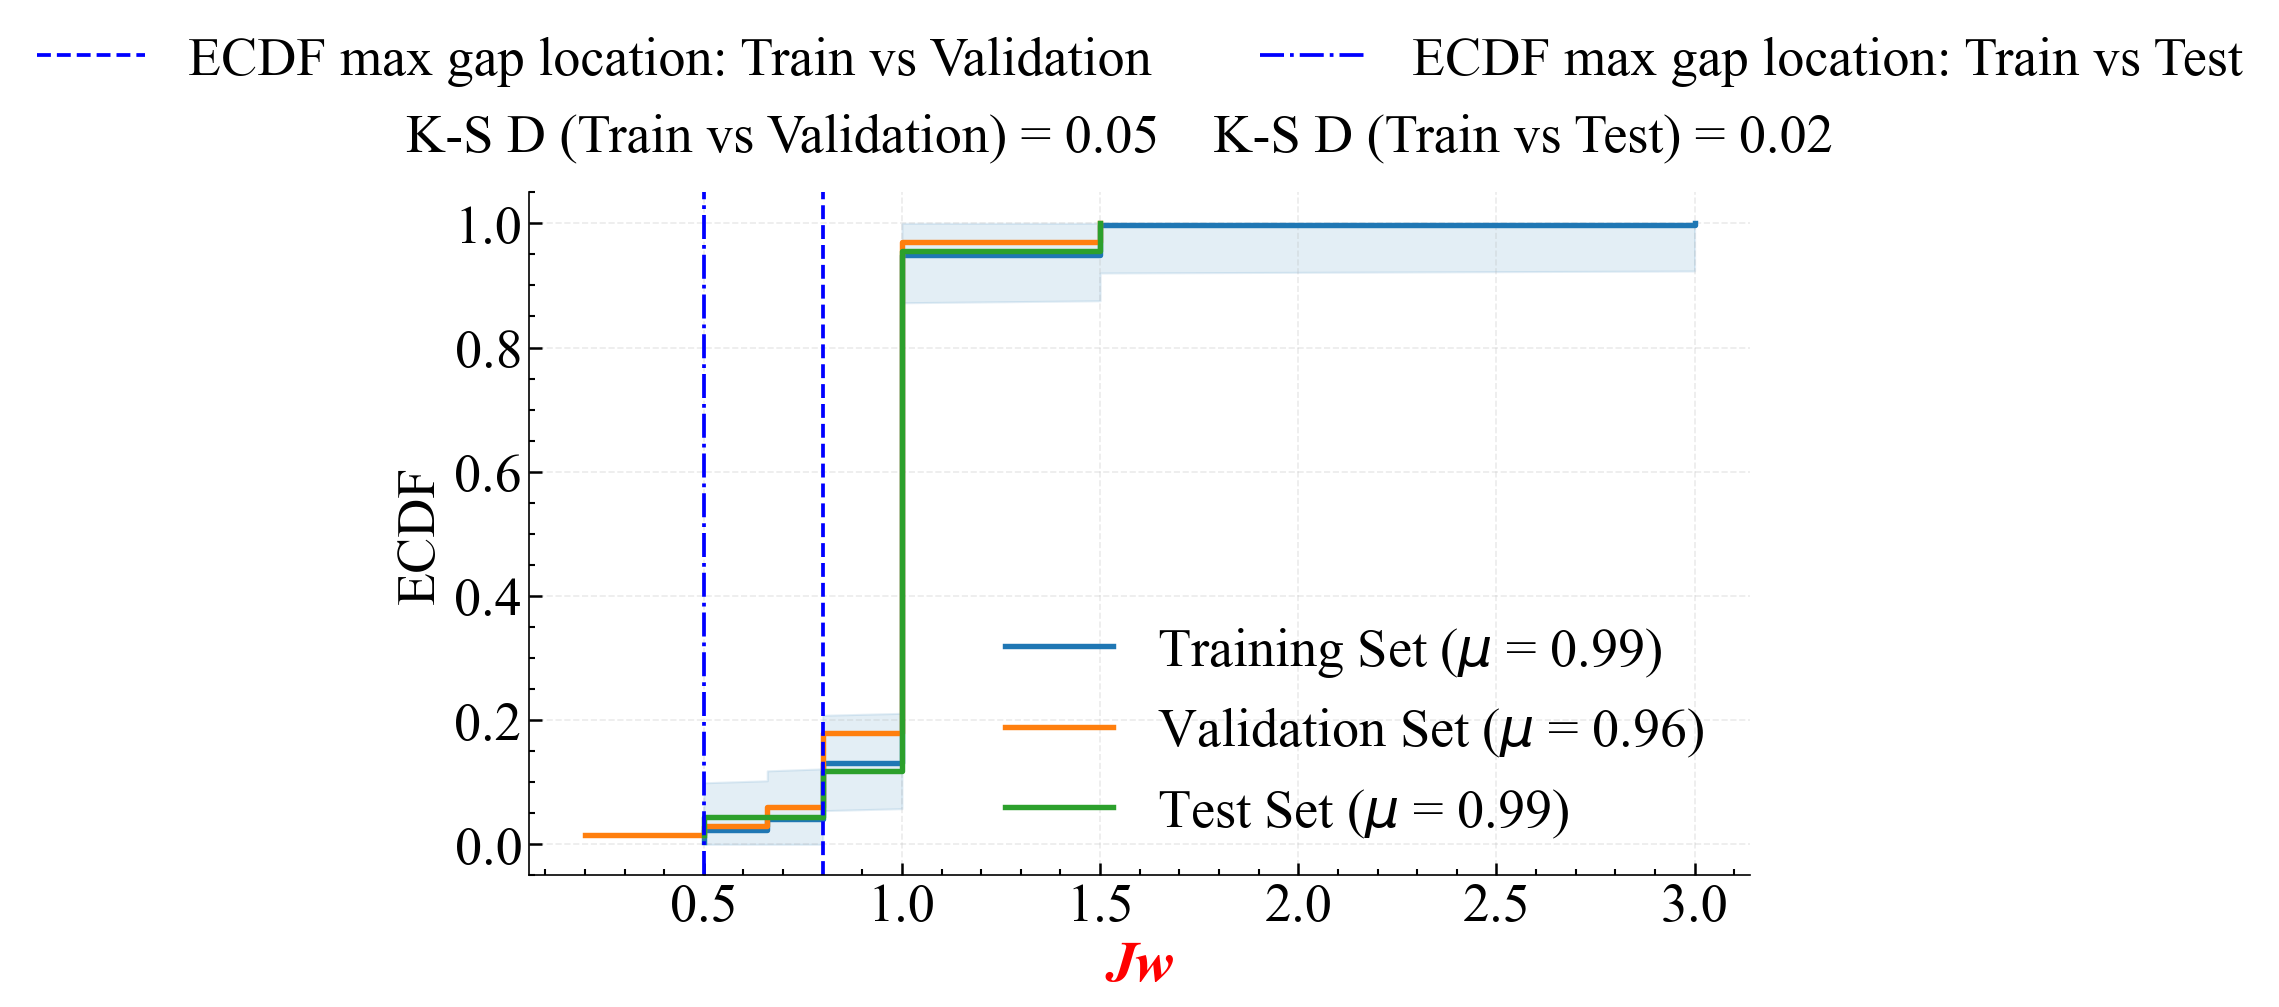

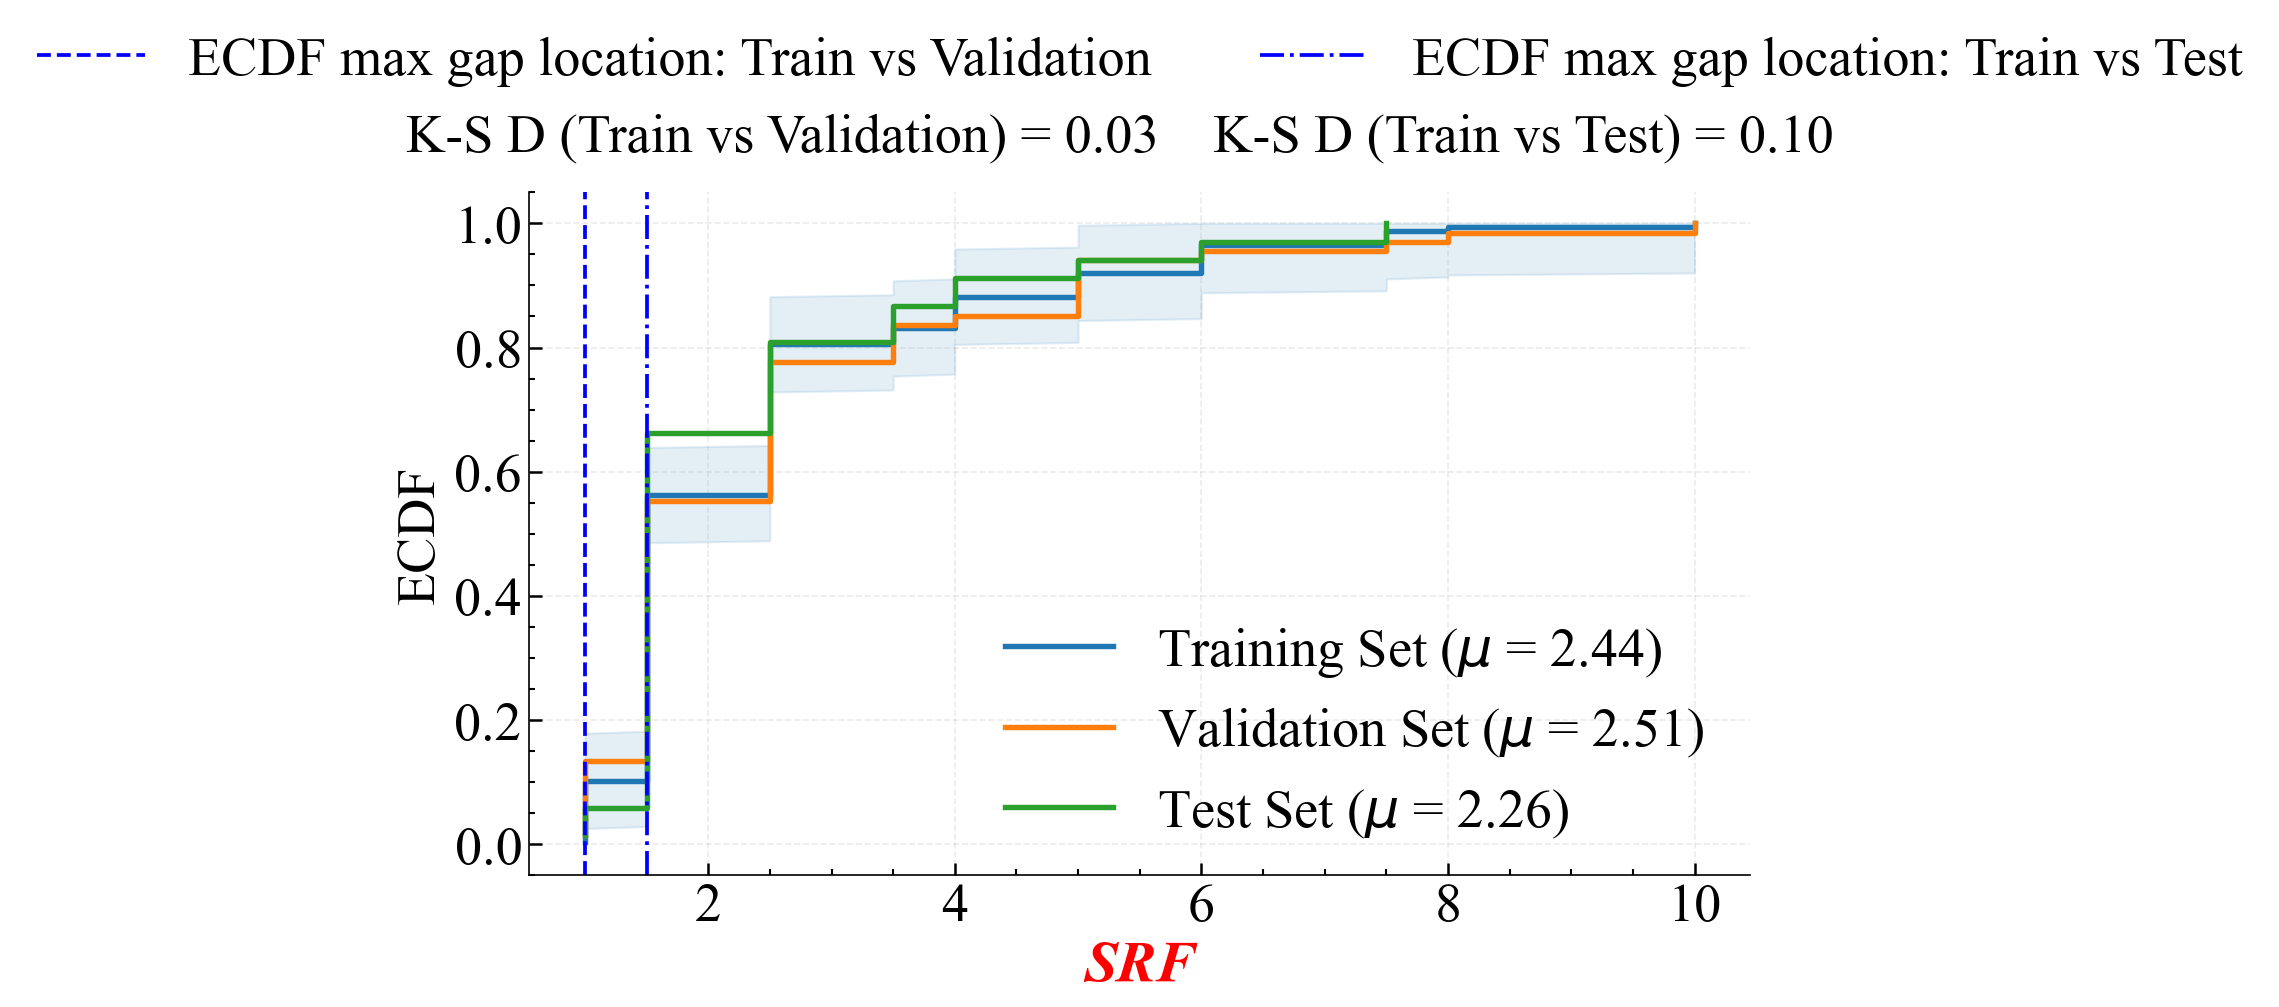

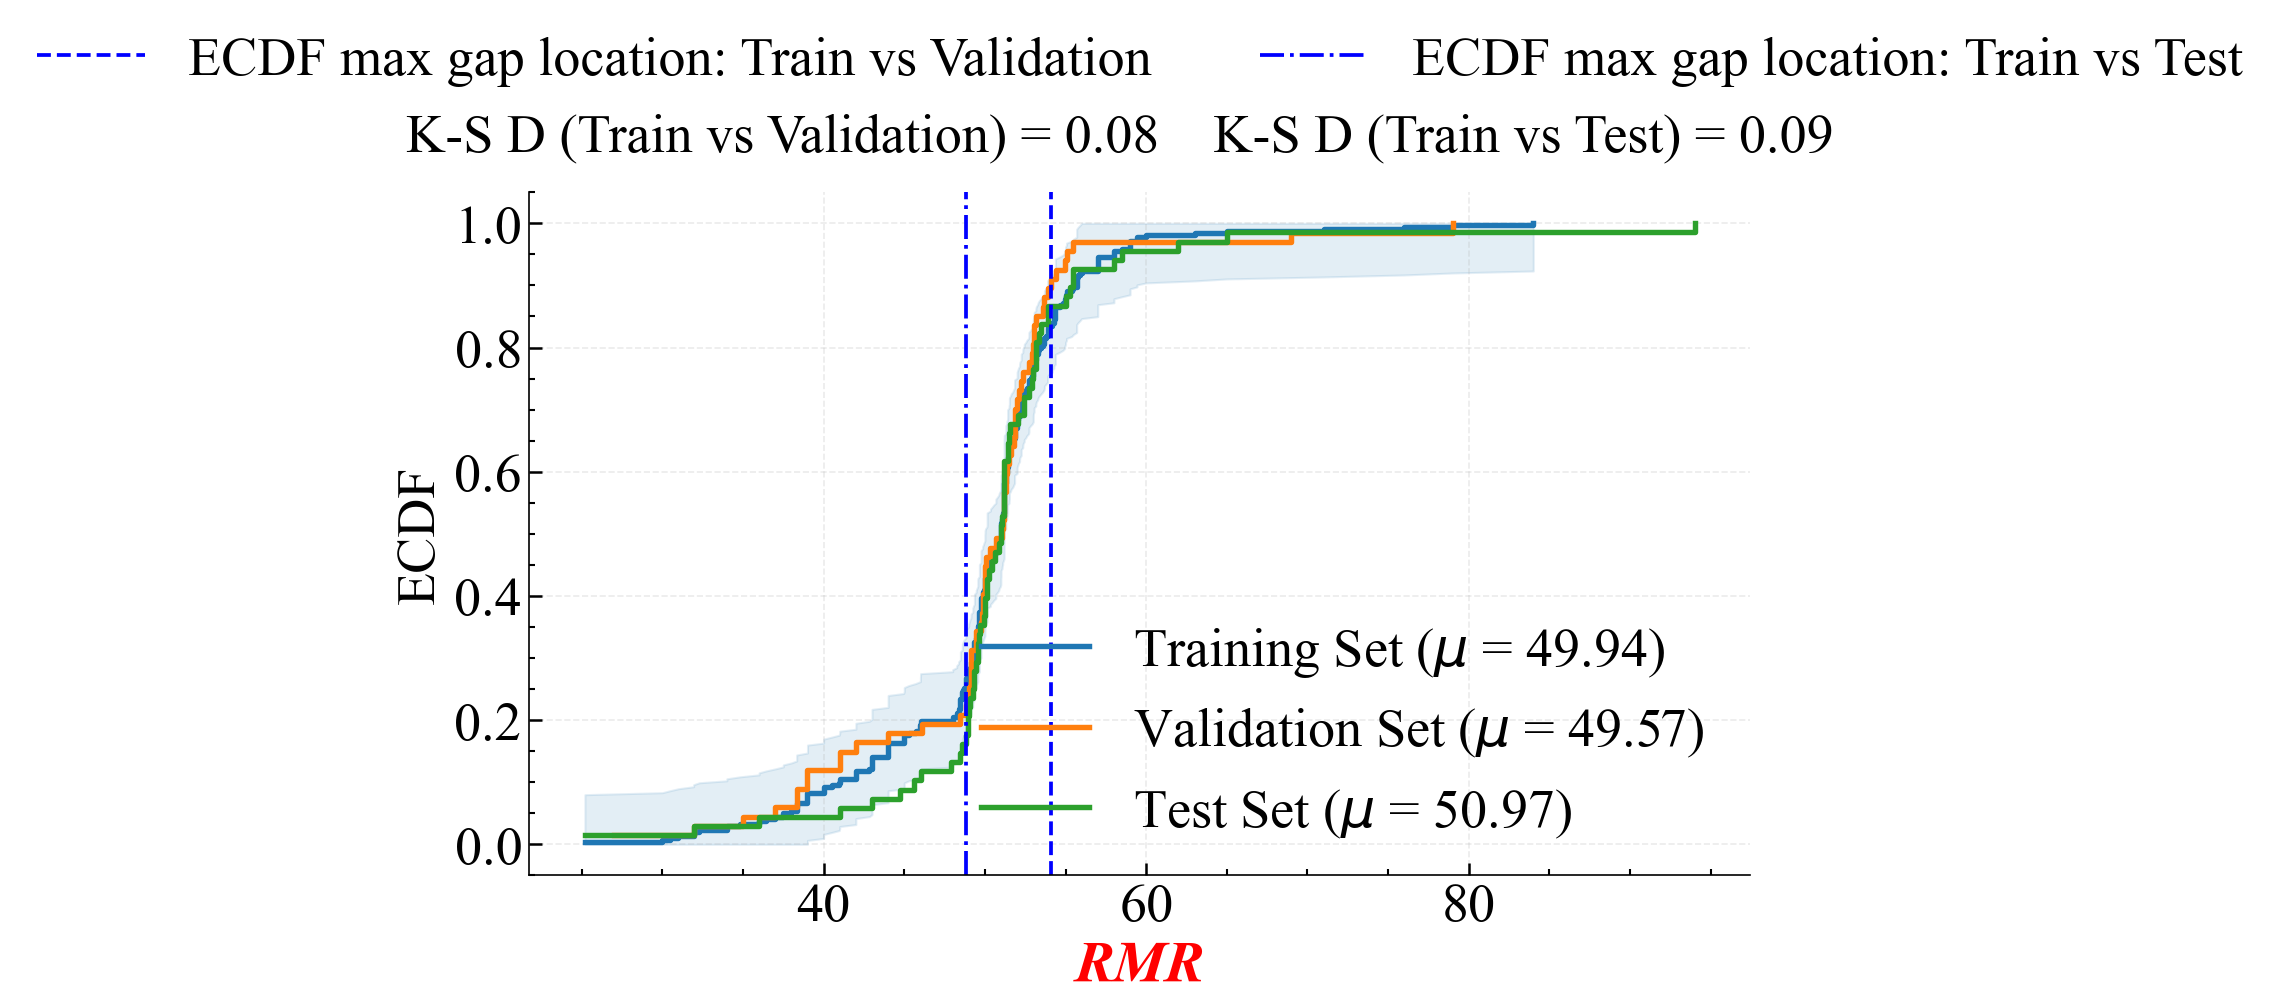

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_PATH = "Q-RMR Data.xlsx"
SEED = 0

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 20,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
    "legend.fontsize": 26,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
    "lines.linewidth": 2.6,
})

def ecdf(a):
    a = np.asarray(a, dtype=float)
    a = a[~np.isnan(a)]
    a.sort()
    y = np.arange(1, len(a) + 1, dtype=float) / float(len(a))
    return a, y

def ks_stat(x, y):
    xs, _ = ecdf(x)
    ys, _ = ecdf(y)
    grid = np.unique(np.concatenate([xs, ys]))
    Fx = np.searchsorted(xs, grid, side="right") / len(xs)
    Fy = np.searchsorted(ys, grid, side="right") / len(ys)
    d = np.abs(Fx - Fy)
    i = int(np.argmax(d))
    return float(d[i]), float(grid[i])

def dkw_band(x, alpha=0.05):
    xs, Fn = ecdf(x)
    n = max(1, len(xs))
    eps = np.sqrt(np.log(2.0 / alpha) / (2.0 * n))
    lo = np.clip(Fn - eps, 0.0, 1.0)
    hi = np.clip(Fn + eps, 0.0, 1.0)
    return xs, Fn, lo, hi

df = pd.read_excel(DATA_PATH)
cols = ["RQD", "Jn", "Jr", "Ja", "Jw", "SRF", "RMR"]
df = df[cols].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

X = df[["RQD", "Jn", "Jr", "Ja", "Jw", "SRF"]].values
y = df["RMR"].values
idx = df.index.values

X_tr, X_tmp, y_tr, y_tmp, idx_tr, idx_tmp = train_test_split(
    X, y, idx, test_size=0.30, random_state=SEED, shuffle=True
)
X_val, X_te, y_val, y_te, idx_val, idx_te = train_test_split(
    X_tmp, y_tmp, idx_tmp, test_size=0.50, random_state=SEED, shuffle=True
)

def make_df(X, y, idx, split):
    d = pd.DataFrame(X, columns=["RQD", "Jn", "Jr", "Ja", "Jw", "SRF"], index=idx)
    d["RMR"] = y
    d["split"] = split
    return d

D = pd.concat([
    make_df(X_tr, y_tr, idx_tr, "train"),
    make_df(X_val, y_val, idx_val, "val"),
    make_df(X_te, y_te, idx_te, "test")
]).sort_index()

legend_map = {"train": "Training Set", "val": "Validation Set", "test": "Test Set"}

def plot_one_ecdf(D, colname, band_split="train", band_alpha=0.05):
    fig = plt.figure(figsize=(10.5, 6.6))
    gs = fig.add_gridspec(1, 1, top=0.80)
    ax = fig.add_subplot(gs[0])

    handles = []
    means = {}
    series = {}

    for split in ["train", "val", "test"]:
        v = D.loc[D["split"] == split, colname].values
        series[split] = v
        x, y = ecdf(v)
        ln, = ax.step(x, y, where="post")
        handles.append(ln)
        means[split] = float(np.nanmean(v))

    if band_split in series:
        xs, Fn, lo, hi = dkw_band(series[band_split], alpha=band_alpha)
        ax.fill_between(xs, lo, hi, color="#1f77b4", alpha=0.12)

    d_tv, x_tv = ks_stat(series["train"], series["val"])
    d_tt, x_tt = ks_stat(series["train"], series["test"])

    ax.axvline(x_tv, linestyle="--", linewidth=1.8, color="blue")
    ax.axvline(x_tt, linestyle="-.", linewidth=1.8, color="blue")

    ks_text = f"K-S D (Train vs Validation) = {d_tv:.2f}    K-S D (Train vs Test) = {d_tt:.2f}"
    fig.text(0.5, 0.88, ks_text, ha="center", va="top", fontsize=26)

    ks_handles = [
        plt.Line2D([0], [0], color="blue", linestyle="--", lw=1.8, label="ECDF max gap location: Train vs Validation"),
        plt.Line2D([0], [0], color="blue", linestyle="-.", lw=1.8, label="ECDF max gap location: Train vs Test"),
    ]
    ks_leg = ax.legend(handles=ks_handles, loc="upper center", bbox_to_anchor=(0.5, 1.30), ncol=2, frameon=False)
    fig.add_artist(ks_leg)

    ax.minorticks_on()
    ax.tick_params(direction="in", which="major", length=6, width=1.2)
    ax.tick_params(direction="in", which="minor", length=3, width=1.0)

    ax.set_xlabel(colname, color="red", fontweight="bold", fontstyle="italic", fontsize=28)
    ax.set_ylabel("ECDF")

    labels = [
        f"{legend_map['train']} ($\\mu$ = {means['train']:.2f})",
        f"{legend_map['val']} ($\\mu$ = {means['val']:.2f})",
        f"{legend_map['test']} ($\\mu$ = {means['test']:.2f})",
    ]

    if colname in {"RQD", "Jn"}:
        ax.legend(handles, labels, ncol=1, loc="upper left", bbox_to_anchor=(0.02, 0.98), borderaxespad=0.0)
    else:
        ax.legend(handles, labels, ncol=1, loc="lower right", bbox_to_anchor=(0.98, 0.02), borderaxespad=0.0)

    plt.show()
    plt.close(fig)

for c in ["RQD", "Jn", "Jr", "Ja", "Jw", "SRF", "RMR"]:
    plot_one_ecdf(D, c)